# Audit: Galaxy Zoo 1 classes (E/S/U/X) versus Domínguez Sánchez et al. (2018)

**Status: temporary diagnostic notebook.** It reads repository data and an external catalogue, and
writes nothing into the repository (the only cache it uses lives under `~/.cache/cg_gals_audit/`).
It does not alter the pipeline, manuscript, configuration, figures or any data file.

## 1. Objective

Our morphology classes come from Galaxy Zoo 1 (GZ1) debiased vote fractions and are labelled
*Elliptical*, *Spiral*, *Uncertain* (finite votes, no threshold crossed) and *NoGZ* (no GZ1 votes).
Below these are abbreviated **E / S / U / X**.

Domínguez Sánchez et al. (2018, MNRAS 476, 3661; DS18) provide deep-learning morphologies for
~670 000 SDSS DR7 galaxies, including a continuous `TType` and a probability `P_S0` designed to
separate S0 from pure ellipticals *within the early-type population* (`TType <= 0`).

Two questions:

1. **S0 fate** — when DS18 says an early-type galaxy is S0-like rather than elliptical, where does
   our GZ1 scheme put it (E, S, U or X)?  This is $P(\text{our class}\mid\text{DS18 morphology})$.
2. **Content of our classes** — what DS18 morphologies live inside our E, S, U and X?  This is
   $P(\text{DS18 morphology}\mid\text{our class})$.

The unit of analysis is the **unique galaxy (unique SDSS objID)**, not the sample row: galaxies
that appear in several control samples are counted once.

In [1]:
import os, re, io, sys, gzip, json, time, textwrap, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
DATA = REPO / "data"
PKL = DATA / "processed_sample.pkl"

# All external / derived material goes OUTSIDE the repository.
CACHE = Path.home() / ".cache" / "cg_gals_audit"
CACHE.mkdir(parents=True, exist_ok=True)

print("repo :", REPO)
print("cache:", CACHE)
assert PKL.exists(), PKL

repo : /Users/matt/Astrophysics/CG_Gals
cache: /Users/matt/.cache/cg_gals_audit


## 2. Existing GZ1 classification (as implemented in the repository)

Derived by reading the code, not from any assumption:

* **Working tables**: `data/processed_sample.pkl` (written by `src/main.py::sSFR_properties`), a dict with
  `CG4_Gals`, `RG4_Gals`, `Control4B_Gals`, `Control4C_Gals` (one row per galaxy *per sample*) and the
  parent `SDSS` / `SDSS_withAGN` tables.
* **GZ1 columns**: `src/data_loader.py::load_SDSS` queries SDSS **DR16** (`config.DATA_RELEASE = 16`) and
  takes `zooSpec.p_el_debiased AS p_E` and `zooSpec.p_cs_debiased AS p_S`, joined on `specObjID`.
  So the vote fractions are the **debiased** GZ1 fractions for *elliptical* and *combined spiral*
  (`p_cs` = clockwise + anticlockwise + edge-on spiral).  The `zooSpec` table only contains
  galaxies with GZ1 spectroscopic classifications.
* **Identifier**: the retained id is `PhotoObj.objID` from DR16 (via `SpecObj.bestObjID`), renamed `objid`
  (int64).  `src/main.py` merges `p_E`, `p_S` from `SDSS_withAGN` into each sample table with a left join on
  `objid`.  **This is a DR8+ objID (prefix `1237…`), not a DR7 objID (prefix `5877…`).**
* **Thresholds / definitions** (`src/morphologies.py::classify`, constants from `src/config.py`):

```python
finite_votes = p_E.notna() & p_S.notna()
morphology = 'NoGZ'                                     # default   -> X
morphology[finite_votes]                    = 'Uncertain'  # -> U
morphology[finite_votes & (p_E > 0.5)]      = 'Elliptical' # -> E
morphology[finite_votes & ~(p_E > 0.5) & (p_S > 0.5)] = 'Spiral'  # -> S
```

  * **E**: `p_E > 0.5` (debiased elliptical fraction above one half).
  * **S**: `p_E <= 0.5` and `p_S > 0.5`.
  * **U**: both fractions finite but neither exceeds 0.5.
  * **X** (`NoGZ`): `p_E` or `p_S` missing, i.e. the galaxy has **no GZ1 `zooSpec` entry** (the DR16
    `zooSpec` join found no row for that `specObjID`, or the sample `objid` was not in the parent SDSS
    query).  It is a *data-availability* class, not a morphological judgement.

Nothing about this implementation is changed here; the cell below prints the live function source
from the repository (read-only) and the next section re-derives the labels from `p_E`, `p_S` with the
same rule to confirm the pickle is consistent with the code.

In [2]:
src = (REPO / "src" / "morphologies.py").read_text()
m = re.search(r"def classify\(df.*?\n    return df\n", src, flags=re.S)
print(m.group(0))
cfg = (REPO / "src" / "config.py").read_text()
print("\n".join(l for l in cfg.splitlines() if l.startswith(("Morphologies", "NoMorphology_LABEL", "DATA_RELEASE"))))

def classify(df: pd.DataFrame) -> pd.DataFrame:
    """
    Assign a morphological class to each galaxy based on debiased Galaxy Zoo vote fractions.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame must contain the following columns:
        - 'p_E' : float  
            Debiased vote fraction for the elliptical classification.
        - 'p_S' : float  
            Debiased vote fraction for the spiral classification.

    Returns
    -------
    pandas.DataFrame
        The original DataFrame augmented with:
        - 'morphology' : str
            Assigned morphological class, one of:
            'Elliptical', 'Spiral', 'Uncertain', or the project missing-vote
            label. ``Uncertain`` means finite Galaxy Zoo votes that do not
            cross either threshold; missing vote fractions are not folded into
            that class.
    """
    p_e = pd.to_numeric(df.get('p_E', pd.Series(np.nan, index=df.index)), errors='coerce')
    p_s = pd.to_nume

## 3. Loading our sample

Build one row per **unique objid** with the GZ1 quantities and sample-membership flags.
Sample membership is kept as boolean columns; the morphology quantities are verified to be identical
across the samples a galaxy belongs to.

In [3]:
import pickle
with open(PKL, "rb") as fh:
    sample = pickle.load(fh)

GAL_TABLES = ["CG4_Gals", "RG4_Gals", "Control4B_Gals", "Control4C_Gals"]
SHORT = {"Elliptical": "E", "Spiral": "S", "Uncertain": "U", "NoGZ": "X"}
CLASSES = ["E", "S", "U", "X"]

rows = []
for tab in GAL_TABLES:
    df = sample[tab][["objid", "specobjid", "RA", "Dec", "z", "lgm", "rank_M", "p_E", "p_S", "morphology"]].copy()
    df["objid"] = df["objid"].astype("int64")
    df["sample"] = tab.replace("_Gals", "")
    rows.append(df)
long = pd.concat(rows, ignore_index=True)
print("rows over all sample tables:", len(long))
print(long.groupby("sample")["morphology"].value_counts().unstack().fillna(0).astype(int))

# Re-derive the label with the repository rule to prove the pickle matches the code.
pe = pd.to_numeric(long["p_E"], errors="coerce"); ps = pd.to_numeric(long["p_S"], errors="coerce")
fin = pe.notna() & ps.notna()
rederived = pd.Series("NoGZ", index=long.index, dtype=object)
rederived[fin] = "Uncertain"; rederived[fin & (pe > 0.5)] = "Elliptical"; rederived[fin & ~(pe > 0.5) & (ps > 0.5)] = "Spiral"
assert (rederived == long["morphology"]).all(), "pickle morphology differs from classify() rule"
print("\nRe-derived labels identical to stored 'morphology': OK")

# Consistency of the GZ1 quantities across samples for the same galaxy
chk = long.groupby("objid").agg(n_morph=("morphology", "nunique"),
                                n_pE=("p_E", lambda v: v.round(6).nunique(dropna=False)))
assert (chk["n_morph"] == 1).all() and (chk["n_pE"] == 1).all()
print("GZ1 quantities identical across samples for every objid: OK")

# One row per unique galaxy + membership flags
first = long.drop_duplicates("objid").set_index("objid")
mem = long.pivot_table(index="objid", columns="sample", values="morphology", aggfunc="size").fillna(0).gt(0)
mem.columns = ["in_" + c for c in mem.columns]
ours = first[["specobjid", "RA", "Dec", "z", "lgm", "p_E", "p_S", "morphology"]].join(mem)
ours["gz1_class"] = ours["morphology"].map(SHORT)
ours["is_CG"] = ours["in_CG4"]
ours["is_control"] = ours[["in_RG4", "in_Control4B", "in_Control4C"]].any(axis=1) & ~ours["is_CG"]
assert not (ours["is_CG"] & ours["is_control"]).any()

print("\nunique galaxies:", len(ours))
print(ours["gz1_class"].value_counts().reindex(CLASSES))
print("\nmembership (unique galaxies):")
print(ours[[c for c in ours.columns if c.startswith("in_")] + ["is_CG", "is_control"]].sum())

rows over all sample tables: 6076
morphology  Elliptical  NoGZ  Spiral  Uncertain
sample                                         
CG4                124    31      86          7
Control4B         1106   304    1266        116
Control4C         1118   321    1229        144
RG4                 60    20     129         15

Re-derived labels identical to stored 'morphology': OK
GZ1 quantities identical across samples for every objid: OK

unique galaxies: 3857
gz1_class
E    1532
S    1728
U     175
X     422
Name: count, dtype: int64

membership (unique galaxies):
in_CG4           248
in_Control4B    2792
in_Control4C    2812
in_RG4           224
is_CG            248
is_control      3609
dtype: int64


## 4. Loading DS18

**Source.** The catalogue is not present anywhere in the repository (`grep -ri "TType\|DS18\|Dominguez"`
over `src/`, `data/`, `analysis/`, `notebooks/` returns nothing).  It is fetched from the CDS/VizieR
archive of the paper, **J/MNRAS/476/3661** (`catalog.dat.gz`, 670 722 rows, plus the `ReadMe`), at
`https://cdsarc.cds.unistra.fr/ftp/J/MNRAS/476/3661/`, and cached under `~/.cache/cg_gals_audit/ds18/`
— outside the repository, so it is **not** added as a data dependency.

The file is fixed-width; the `ReadMe` byte layout is used to parse it.  The identifier column is
documented by CDS as **`objID` — "SDSS DR7 objID (dr7objid)"**.  `PS0` is documented as "Probability of being
S0 versus E … Only meaningful for T-Type <= 0", and `Pedgeon` as "Probability of being edge on".
The `objID` column is read as a string and converted to `int64` so that no value passes through
floating point.

In [4]:
DS18_DIR = CACHE / "ds18"; DS18_DIR.mkdir(exist_ok=True)
BASE = "https://cdsarc.cds.unistra.fr/ftp/J/MNRAS/476/3661/"
import urllib.request
for fn in ("ReadMe", "catalog.dat.gz"):
    if not (DS18_DIR / fn).exists():
        print("downloading", BASE + fn)
        urllib.request.urlretrieve(BASE + fn, DS18_DIR / fn)
    print(fn, (DS18_DIR / fn).stat().st_size, "bytes")

# Byte-by-byte description from the ReadMe (1-based inclusive byte ranges)
colspecs = [(0, 19), (20, 26), (27, 38), (39, 50), (51, 62), (63, 74), (75, 86), (87, 98), (99, 110), (111, 119), (120, 131)]
names = ["objID", "M15", "P_disk", "P_edge_on", "P_bar_GZ2", "P_bar_Nair10", "P_merg", "P_bulge", "P_cigar", "TType", "P_S0"]
with gzip.open(DS18_DIR / "catalog.dat.gz", "rt") as fh:
    ds18 = pd.read_fwf(fh, colspecs=colspecs, names=names, header=None, dtype={"objID": str})
ds18["objID"] = ds18["objID"].str.strip().astype("int64")
for c in names[1:]:
    ds18[c] = pd.to_numeric(ds18[c], errors="coerce")

print(ds18.dtypes)
print("\nrows:", len(ds18), " unique objID:", ds18["objID"].nunique())
print("TType range:", ds18["TType"].min(), ds18["TType"].max(), " | P_S0 range:", ds18["P_S0"].min(), ds18["P_S0"].max())
print("first objIDs:", ds18["objID"].head(3).tolist())
ds18.head()

ReadMe 5862 bytes
catalog.dat.gz 30739406 bytes


objID             int64
M15               int64
P_disk          float64
P_edge_on       float64
P_bar_GZ2       float64
P_bar_Nair10    float64
P_merg          float64
P_bulge         float64
P_cigar         float64
TType           float64
P_S0            float64
dtype: object

rows: 670722  unique objID: 670722
TType range: -3.31226 8.00328  | P_S0 range: 0.0105889 0.999991
first objIDs: [587722952230174996, 587722952230175035, 587722952230175138]


,objID,M15,P_disk,P_edge_on,P_bar_GZ2,P_bar_Nair10,P_merg,P_bulge,P_cigar,TType,P_S0
0,587722952230174996,1,0.000035,0.646749,0.005703,0.384967,0.021090,0.002234,0.992602,3.40424,0.970816
1,587722952230175035,2,0.000726,0.005197,0.000318,0.360790,0.097683,0.000533,0.999629,3.32452,0.999759
2,587722952230175138,3,0.966147,0.000430,0.001168,0.396651,0.039528,0.277210,0.143814,2.18678,0.995247
3,587722952230175145,4,0.076529,0.000010,0.001635,0.344985,0.051897,0.061610,0.000900,1.80833,0.998581
4,587722952230175173,5,0.588999,0.053386,0.000710,0.462225,0.043130,0.254238,0.974827,2.63448,0.999394


## 5. Cross-match validation

### 5.1 The two `objID`s are *not* the same identifier

SDSS object IDs encode `skyVersion` in the top bits.  DR7 photometric objIDs have `skyVersion = 1`
(decimal prefix `5877…`); DR8 and later re-ran the photometric pipeline and issued new objIDs with
`skyVersion = 2` (prefix `1237…`).  Our `objid` comes from a DR16 query, DS18's `objID` is a DR7 id.
The cell below confirms this structurally and shows that a naive ID join matches nothing.

In [5]:
def sky_version(objid):
    return (np.asarray(objid, dtype=np.int64) >> 59) & 0xF   # SDSS objID bit layout: skyVersion occupies bits 59-62

print("our objid   : dtype", ours.index.dtype, "| skyVersion values", np.unique(sky_version(ours.index.values)),
      "| example", ours.index[0])
print("DS18 objID  : dtype", ds18["objID"].dtype, "| skyVersion values", np.unique(sky_version(ds18["objID"].values)),
      "| example", ds18["objID"].iloc[0])
naive = ours.index.isin(ds18["objID"].values).sum()
print("\nnaive join on raw id values ->", naive, "matches (expected 0: different identifier families)")
assert naive == 0

our objid   : dtype int64 | skyVersion values [2] | example 1237655108898979844
DS18 objID  : dtype int64 | skyVersion values [1] | example 587722952230174996

naive join on raw id values -> 0 matches (expected 0: different identifier families)


### 5.2 Obtain the DR7 objID for each of our galaxies

SDSS DR8+ publishes the table **`PhotoObjDR7`** (one row per DR8 object, giving `dr7objid`, `dr8objid`,
the DR7 `ra`, `dec` and the DR7↔DR8 positional `distance` in arcmin).  It is queried through the same
`astroquery.sdss` SkyServer endpoint the pipeline uses (`data_release=16`), in chunks, and the result is
cached outside the repository.  Integer ids are transported as strings inside the SQL text and read
back as `int64`; when attached to our table they are kept in the nullable `Int64` dtype so that missing
values never force a float64 cast (a first attempt with a plain left join did exactly that and corrupted
the low-order digits — the round-trip assertion below guards against it).

Validation steps:
* every one of our `objid`s must be found, exactly once, in `PhotoObjDR7`;
* the DR7 position must coincide with our own `RA, Dec` (< 1 arcsec);
* the `dr7objid` must have DR7 `skyVersion = 1`.

In [6]:
from astroquery.sdss import SDSS

MAP_FILE = CACHE / "photoobjdr7_map.csv"
need = np.sort(ours.index.values.astype("int64"))

QUERIED_FILE = CACHE / "photoobjdr7_queried_dr8objids.txt"   # ids already asked for (some have no DR7 row)
dr7map = None
if MAP_FILE.exists() and QUERIED_FILE.exists():
    queried = set(int(x) for x in QUERIED_FILE.read_text().split())
    if set(need).issubset(queried):
        dr7map = pd.read_csv(MAP_FILE, dtype={"dr7objid": "int64", "dr8objid": "int64"})
        print("using cached PhotoObjDR7 mapping:", MAP_FILE)

if dr7map is None:
    parts = []
    CH = 200
    for i in range(0, len(need), CH):
        ids = ",".join(str(x) for x in need[i:i + CH])
        q = f"SELECT dr7objid, dr8objid, ra, dec, distance FROM PhotoObjDR7 WHERE dr8objid IN ({ids})"
        for attempt in range(4):
            try:
                r = SDSS.query_sql(q, data_release=16, timeout=120)
                break
            except Exception as exc:
                print(f"chunk {i//CH}: attempt {attempt} failed ({exc}); retrying")
                time.sleep(5 * (attempt + 1))
        else:
            raise RuntimeError("PhotoObjDR7 query failed repeatedly")
        p = r.to_pandas() if r is not None else pd.DataFrame(columns=["dr7objid", "dr8objid", "ra", "dec", "distance"])
        parts.append(p)
        print(f"chunk {i//CH + 1}/{(len(need) - 1)//CH + 1}: {len(p)} rows", end="\r")
    dr7map = pd.concat(parts, ignore_index=True)
    dr7map["dr7objid"] = dr7map["dr7objid"].astype("int64"); dr7map["dr8objid"] = dr7map["dr8objid"].astype("int64")
    dr7map.to_csv(MAP_FILE, index=False); QUERIED_FILE.write_text("\n".join(str(x) for x in need))
    print("\nsaved", MAP_FILE)

print("PhotoObjDR7 rows returned:", len(dr7map), "| unique dr8objid:", dr7map["dr8objid"].nunique(),
      "| unique dr7objid:", dr7map["dr7objid"].nunique())
dup8 = dr7map["dr8objid"].duplicated(keep=False).sum(); dup7 = dr7map["dr7objid"].duplicated(keep=False).sum()
print("rows with duplicated dr8objid:", dup8, "| rows with duplicated dr7objid:", dup7)
missing = np.setdiff1d(need, dr7map["dr8objid"].values)
print("our objids without a PhotoObjDR7 row:", len(missing))

# Attach the mapping WITHOUT letting the id pass through float64: a plain left join would introduce NaN
# for the unmapped galaxies and silently upcast the int64 id to float64 (which cannot represent 19-digit
# integers exactly).  Use the nullable Int64 dtype and reindex instead.
mp = dr7map.set_index("dr8objid")
ours["dr7objid"] = mp["dr7objid"].astype("Int64").reindex(ours.index)
assert str(ours["dr7objid"].dtype) == "Int64"
roundtrip = ours["dr7objid"].dropna().astype("int64")
assert roundtrip.isin(mp["dr7objid"].values).all(), "dr7objid values altered during attachment"
print("dr7objid attached as nullable Int64; all", len(roundtrip), "values round-trip exactly: OK")

# positional consistency between our table and DR7 coordinates
ra7 = mp["ra"].reindex(ours.index); dec7 = mp["dec"].reindex(ours.index)
dra = (ours["RA"] - ra7) * np.cos(np.deg2rad(ours["Dec"])) * 3600; ddec = (ours["Dec"] - dec7) * 3600
sep = np.hypot(dra, ddec)
print("our RA/Dec vs DR7 position: median %.3f arcsec, max %.3f arcsec, n>1'' = %d" % (np.nanmedian(sep), np.nanmax(sep), (sep > 1).sum()))
print("DR7<->DR8 'distance' column (arcmin): max %.4f" % mp["distance"].max())
print("skyVersion of dr7objid:", np.unique(sky_version(dr7map["dr7objid"].values)))
ours["sep_dr7_arcsec"] = sep

using cached PhotoObjDR7 mapping: /Users/matt/.cache/cg_gals_audit/photoobjdr7_map.csv
PhotoObjDR7 rows returned: 3607 | unique dr8objid: 3607 | unique dr7objid: 3607
rows with duplicated dr8objid: 0 | rows with duplicated dr7objid: 0
our objids without a PhotoObjDR7 row: 250
dr7objid attached as nullable Int64; all 3607 values round-trip exactly: OK
our RA/Dec vs DR7 position: median 0.018 arcsec, max 0.746 arcsec, n>1'' = 0
DR7<->DR8 'distance' column (arcmin): max 0.0002
skyVersion of dr7objid: [1]


### 5.3 Match on DR7 objID and report

The match is `ours.dr7objid` (int64) ↔ `ds18.objID` (int64).  We additionally keep any galaxy whose DR7
position is more than 1″ from our position flagged, so a bad DR7↔DR8 association cannot pass silently.

In [7]:
ds18_idx = ds18.drop_duplicates("objID").set_index("objID")
have7 = ours["dr7objid"].notna()
ok_pos = ours["sep_dr7_arcsec"] < 1.0
ours_int = ours[have7].copy(); ours_int["dr7objid"] = ours_int["dr7objid"].astype("int64")
aud = (ours_int.reset_index()
       .merge(ds18_idx.reset_index(), left_on="dr7objid", right_on="objID", how="inner", validate="1:1")
       .set_index("objid").drop(columns="objID"))
aud = aud[aud["sep_dr7_arcsec"] < 1.0]
assert aud.index.is_unique and aud["dr7objid"].is_unique

report = {
    "Our rows (all sample tables)": len(long),
    "Our unique objIDs": int(ours.index.nunique()),
    "DS18 rows": len(ds18),
    "DS18 unique objIDs": int(ds18["objID"].nunique()),
    "Matched unique galaxies": len(aud),
    "Unmatched unique galaxies": int(len(ours) - len(aud)),
    "Duplicate IDs in our data (unique table)": int(ours.index.duplicated().sum()),
    "Duplicate IDs in our data (rows repeated across samples)": int(len(long) - ours.index.nunique()),
    "Duplicate IDs in DS18": int(ds18["objID"].duplicated().sum()),
    "Our galaxies with no DR7 counterpart": int((~have7).sum()),
    "Our galaxies with DR7 position offset > 1 arcsec": int((have7 & ~ok_pos).sum()),
}
for k, v in report.items():
    print(f"{k:60s} {v}")

CROSSMATCH_VALID = (report["Duplicate IDs in DS18"] == 0 and len(aud) > 0
                    and report["Our galaxies with DR7 position offset > 1 arcsec"] == 0)
print("\nCROSSMATCH_VALID =", CROSSMATCH_VALID)
if not CROSSMATCH_VALID:
    raise SystemExit("Cross-match not demonstrably valid; scientific analysis stopped.")

print("\nmatched fraction by our class:")
print(pd.DataFrame({"n_unique": ours["gz1_class"].value_counts().reindex(CLASSES),
                    "n_matched": aud["gz1_class"].value_counts().reindex(CLASSES)}).assign(frac=lambda d: (d.n_matched / d.n_unique).round(3)))
print("\nmatched fraction by environment:")
print(pd.DataFrame({"n_unique": [ours.is_CG.sum(), ours.is_control.sum()],
                    "n_matched": [aud.is_CG.sum(), aud.is_control.sum()]}, index=["CG", "control"]).assign(frac=lambda d: (d.n_matched / d.n_unique).round(3)))

Our rows (all sample tables)                                 6076
Our unique objIDs                                            3857
DS18 rows                                                    670722
DS18 unique objIDs                                           670722
Matched unique galaxies                                      2436
Unmatched unique galaxies                                    1421
Duplicate IDs in our data (unique table)                     0
Duplicate IDs in our data (rows repeated across samples)     2219
Duplicate IDs in DS18                                        0
Our galaxies with no DR7 counterpart                         250
Our galaxies with DR7 position offset > 1 arcsec             0

CROSSMATCH_VALID = True

matched fraction by our class:
           n_unique  n_matched   frac
gz1_class                            
E              1532        942  0.615
S              1728       1249  0.723
U               175        119  0.680
X               422        126  0

### 5.4 The audit table

One row per matched unique galaxy, kept in memory only.  Columns: objid (index, DR16), `dr7objid`,
our `gz1_class` with the `p_E`, `p_S` that produced it, DS18 `TType`, `P_S0`, `P_edge_on` (plus the other
DS18 probabilities), and sample-membership flags.  The continuous DS18 quantities are preserved;
`TType <= 0` (the DS18/ReadMe ETG definition) is used only as a *mask*, and `P_S0` is interpreted only
inside that mask, as prescribed by DS18.

In [8]:
KEEP = ["dr7objid", "gz1_class", "p_E", "p_S", "TType", "P_S0", "P_edge_on", "P_disk", "P_bulge", "P_cigar", "P_merg",
        "lgm", "z", "in_CG4", "in_RG4", "in_Control4B", "in_Control4C", "is_CG", "is_control"]
aud = aud[KEEP].copy()
aud["early"] = aud["TType"] <= 0
print(aud.shape)
print(aud.isna().sum()[lambda s: s > 0])
aud.head()

(2436, 20)
p_E    126
p_S    126
dtype: int64


,dr7objid,gz1_class,p_E,p_S,TType,P_S0,P_edge_on,P_disk,P_bulge,P_cigar,P_merg,lgm,z,in_CG4,in_RG4,in_Control4B,in_Control4C,is_CG,is_control,early
objid,,,,,,,,,,,,,,,,,,,,
1237655108898979844,587729387674075301,S,0.018,0.982,3.43968,0.836481,0.989109,0.930340,0.387578,0.995453,0.399234,11.136960,0.038103,True,False,False,False,True,False,False
1237655108898914500,587729387674009786,E,0.920,0.061,-0.92938,0.913073,0.000009,0.362574,0.989825,0.000027,0.254743,10.407860,0.037865,True,False,False,False,True,False,True
1237655108898914492,587729387674009778,S,0.158,0.757,4.31039,0.876408,0.000280,0.769131,0.027005,0.000646,0.568672,9.313793,0.038568,True,False,False,False,True,False,False
1237655108898980064,587729387674075353,S,0.007,0.993,6.40969,0.570627,0.999998,0.926310,0.000088,1.000000,0.027121,9.284696,0.037564,True,False,False,False,True,False,False
1237651271887618101,587725550662713352,X,NaN,NaN,-1.46000,0.734093,0.939935,0.002114,0.916364,0.997986,0.478097,10.829270,0.046428,True,False,False,False,True,False,True


## 6. Global E/S/U/X versus DS18 comparison

### 6.1 Helper: binomial (Wilson) intervals

In [9]:
from scipy.stats import norm

def wilson(k, n, z=norm.ppf(0.975)):
    k, n = np.asarray(k, float), np.asarray(n, float)
    with np.errstate(divide="ignore", invalid="ignore"):
        p = k / n
        den = 1 + z**2 / n
        cen = (p + z**2 / (2 * n)) / den
        half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return np.where(n > 0, cen - half, np.nan), np.where(n > 0, cen + half, np.nan)

def class_fractions(df, label=""):
    '''Fraction of each of our classes inside df (rows), with Wilson 95% CI.'''
    n = len(df); out = []
    for c in CLASSES:
        k = int((df["gz1_class"] == c).sum()); lo, hi = wilson(k, n)
        out.append(dict(subset=label, cls=c, n=n, k=k, frac=k / n if n else np.nan, lo=float(lo), hi=float(hi)))
    return pd.DataFrame(out)

def fmt_row(df):
    return ", ".join(f"{r.cls}: {100*r.frac:.1f}% [{100*r.lo:.1f}–{100*r.hi:.1f}] ({r.k})" for r in df.itertuples())

### 6.2 $P(\text{DS18 morphology}\mid\text{our class})$ — what is inside E, S, U, X

In [10]:
def ds18_content(df):
    rows = {}
    for c in CLASSES:
        d = df[df["gz1_class"] == c]; e = d[d["early"]]; n = len(d); ne = len(e)
        rows[c] = {
            "n_matched": n,
            "median TType": d["TType"].median(),
            "f(TType>0)": (d["TType"] > 0).mean(),
            "f(TType<=0)": d["early"].mean(),
            "n(TType<=0)": ne,
            "median P_S0 | early": e["P_S0"].median(),
            "f(P_S0<0.2 | early)": (e["P_S0"] < 0.2).mean() if ne else np.nan,
            "f(P_S0>0.5 | early)": (e["P_S0"] > 0.5).mean() if ne else np.nan,
            "f(P_S0>=0.8 | early)": (e["P_S0"] >= 0.8).mean() if ne else np.nan,
            # unconditional (of all galaxies in the class)
            "f(early & P_S0<0.2)": ((d["early"]) & (d["P_S0"] < 0.2)).mean(),
            "f(early & P_S0>=0.8)": ((d["early"]) & (d["P_S0"] >= 0.8)).mean(),
        }
    return pd.DataFrame(rows).T

content = ds18_content(aud)
content.round(3)

,n_matched,median TType,f(TType>0),f(TType<=0),n(TType<=0),median P_S0 | early,f(P_S0<0.2 | early),f(P_S0>0.5 | early),f(P_S0>=0.8 | early),f(early & P_S0<0.2),f(early & P_S0>=0.8)
E,942.0,-2.167,0.079,0.921,868.0,0.603,0.180,0.589,0.311,0.166,0.287
S,1249.0,3.353,0.882,0.118,147.0,0.917,0.007,0.932,0.714,0.001,0.084
U,119.0,-0.496,0.445,0.555,66.0,0.784,0.076,0.682,0.500,0.042,0.277
X,126.0,-0.217,0.484,0.516,65.0,0.599,0.185,0.569,0.323,0.095,0.167


In [11]:
# Wilson intervals for the E-class content (the class we care most about)
E = aud[aud["gz1_class"] == "E"]; Ee = E[E["early"]]
for lab, k, n in [("E: TType>0 (DS18 late type)", (E.TType > 0).sum(), len(E)),
                  ("E: TType<=0 (DS18 early type)", E.early.sum(), len(E)),
                  ("E & early: P_S0<0.2 (strongly E-like)", (Ee.P_S0 < 0.2).sum(), len(Ee)),
                  ("E & early: P_S0>0.5", (Ee.P_S0 > 0.5).sum(), len(Ee)),
                  ("E & early: P_S0>=0.8 (strongly S0-like)", (Ee.P_S0 >= 0.8).sum(), len(Ee)),
                  ("E (all): early & P_S0<0.2", (E.early & (E.P_S0 < 0.2)).sum(), len(E)),
                  ("E (all): early & P_S0>=0.8", (E.early & (E.P_S0 >= 0.8)).sum(), len(E))]:
    lo, hi = wilson(k, n); print(f"{lab:45s} {k:4d}/{n:4d} = {100*k/n:5.1f}%  [{100*lo:.1f}–{100*hi:.1f}]")

E: TType>0 (DS18 late type)                     74/ 942 =   7.9%  [6.3–9.7]
E: TType<=0 (DS18 early type)                  868/ 942 =  92.1%  [90.3–93.7]
E & early: P_S0<0.2 (strongly E-like)          156/ 868 =  18.0%  [15.6–20.7]
E & early: P_S0>0.5                            511/ 868 =  58.9%  [55.6–62.1]
E & early: P_S0>=0.8 (strongly S0-like)        270/ 868 =  31.1%  [28.1–34.3]
E (all): early & P_S0<0.2                      156/ 942 =  16.6%  [14.3–19.1]
E (all): early & P_S0>=0.8                     270/ 942 =  28.7%  [25.9–31.6]


### 6.3 $P(\text{our class}\mid\text{DS18 morphology})$ — coarse DS18 bins

Descriptive bins only: DS18 late (`TType > 0`), DS18 early split by `P_S0` bands.

In [12]:
def ds18_bin(df):
    b = pd.Series("late (TType>0)", index=df.index, dtype=object)
    e = df["early"]
    b[e & (df.P_S0 < 0.2)] = "early, P_S0<0.2"
    b[e & (df.P_S0 >= 0.2) & (df.P_S0 < 0.5)] = "early, 0.2<=P_S0<0.5"
    b[e & (df.P_S0 >= 0.5) & (df.P_S0 < 0.8)] = "early, 0.5<=P_S0<0.8"
    b[e & (df.P_S0 >= 0.8)] = "early, P_S0>=0.8"
    return b
BIN_ORDER = ["late (TType>0)", "early, P_S0<0.2", "early, 0.2<=P_S0<0.5", "early, 0.5<=P_S0<0.8", "early, P_S0>=0.8"]
aud["ds18_bin"] = pd.Categorical(ds18_bin(aud), categories=BIN_ORDER, ordered=True)

ct = pd.crosstab(aud["ds18_bin"], aud["gz1_class"]).reindex(columns=CLASSES)
ct["N"] = ct.sum(axis=1)
print("counts:"); print(ct)
print("\nrow fractions P(our class | DS18 bin):"); print((ct[CLASSES].div(ct["N"], axis=0)).round(3))
print("\ncolumn fractions P(DS18 bin | our class):"); print((ct[CLASSES] / ct[CLASSES].sum()).round(3))

counts:
gz1_class               E     S   U   X     N
ds18_bin                                     
late (TType>0)         74  1102  53  61  1290
early, P_S0<0.2       156     1   5  12   174
early, 0.2<=P_S0<0.5  201     9  16  16   242
early, 0.5<=P_S0<0.8  241    32  12  16   301
early, P_S0>=0.8      270   105  33  21   429

row fractions P(our class | DS18 bin):
gz1_class                 E      S      U      X
ds18_bin                                        
late (TType>0)        0.057  0.854  0.041  0.047
early, P_S0<0.2       0.897  0.006  0.029  0.069
early, 0.2<=P_S0<0.5  0.831  0.037  0.066  0.066
early, 0.5<=P_S0<0.8  0.801  0.106  0.040  0.053
early, P_S0>=0.8      0.629  0.245  0.077  0.049

column fractions P(DS18 bin | our class):
gz1_class                 E      S      U      X
ds18_bin                                        
late (TType>0)        0.079  0.882  0.445  0.484
early, P_S0<0.2       0.166  0.001  0.042  0.095
early, 0.2<=P_S0<0.5  0.213  0.007  0.134  0.127

## 7. S0-specific analysis

DS18 define `P_S0` as the probability of being S0 *versus* E, trained on Nair & Abraham (2010) early types,
and state it is only meaningful for `TType <= 0`.  Everything below is restricted to that early-type subset.
Thresholds 0.2 / 0.5 / 0.8 are descriptive, not physical.

### 7.A `P_S0` and `TType` within our classes

In [13]:
qs = [0.1, 0.25, 0.5, 0.75, 0.9]
rowsA = {}
for c in CLASSES:
    d = aud[aud.gz1_class == c]; e = d[d.early]
    r = {"n_matched": len(d), "n(TType<=0)": len(e), "median TType (all)": d.TType.median(), "median TType (early)": e.TType.median(),
         "median P_S0 (early)": e.P_S0.median()}
    r.update({f"P_S0 q{int(q*100)} (early)": e.P_S0.quantile(q) for q in qs})
    rowsA[c] = r
pd.DataFrame(rowsA).T.round(3)

,n_matched,n(TType<=0),median TType (all),median TType (early),median P_S0 (early),P_S0 q10 (early),P_S0 q25 (early),P_S0 q50 (early),P_S0 q75 (early),P_S0 q90 (early)
E,942.0,868.0,-2.167,-2.192,0.603,0.136,0.273,0.603,0.846,0.921
S,1249.0,147.0,3.353,-1.327,0.917,0.591,0.761,0.917,0.961,0.983
U,119.0,66.0,-0.496,-1.706,0.784,0.228,0.390,0.784,0.951,0.986
X,126.0,65.0,-0.217,-2.133,0.599,0.140,0.256,0.599,0.834,0.944


### 7.B Where do increasingly S0-like early types go?

In [14]:
early = aud[aud.early]
edges = [(0.0, 0.2, "P_S0 < 0.2"), (0.2, 0.5, "0.2 <= P_S0 < 0.5"), (0.5, 0.8, "0.5 <= P_S0 < 0.8"), (0.8, 1.01, "P_S0 >= 0.8")]
tabB = pd.concat([class_fractions(early[(early.P_S0 >= lo) & (early.P_S0 < hi)], lab) for lo, hi, lab in edges])
pivotB = tabB.pivot(index="subset", columns="cls", values="frac").reindex([e[2] for e in edges])[CLASSES]
pivotB["N"] = tabB.groupby("subset")["n"].first().reindex(pivotB.index)
print("P(our class | TType<=0, P_S0 bin):"); print(pivotB.round(3))
print()
for lo, hi, lab in edges:
    print(f"{lab:18s} N={len(early[(early.P_S0 >= lo) & (early.P_S0 < hi)]):4d} ->", fmt_row(tabB[tabB.subset == lab]))

hi_s0 = early[early.P_S0 >= 0.8]; incl_s0 = early[early.P_S0 > 0.5]; pure_e = early[early.P_S0 < 0.2]
KEY = class_fractions(hi_s0, "TType<=0 & P_S0>=0.8"); INCL = class_fractions(incl_s0, "TType<=0 & P_S0>0.5"); PURE = class_fractions(pure_e, "TType<=0 & P_S0<0.2")
print("\nKEY   TType<=0, P_S0>=0.8  (N=%d): " % len(hi_s0) + fmt_row(KEY))
print("INCL  TType<=0, P_S0>0.5   (N=%d): " % len(incl_s0) + fmt_row(INCL))
print("REF   TType<=0, P_S0<0.2   (N=%d): " % len(pure_e) + fmt_row(PURE))
print("ALL   TType<=0             (N=%d): " % len(early) + fmt_row(class_fractions(early, "early")))
print("LATE  TType>0              (N=%d): " % (~aud.early).sum() + fmt_row(class_fractions(aud[~aud.early], "late")))

P(our class | TType<=0, P_S0 bin):
cls                    E      S      U      X    N
subset                                            
P_S0 < 0.2         0.897  0.006  0.029  0.069  174
0.2 <= P_S0 < 0.5  0.831  0.037  0.066  0.066  242
0.5 <= P_S0 < 0.8  0.801  0.106  0.040  0.053  301
P_S0 >= 0.8        0.629  0.245  0.077  0.049  429

P_S0 < 0.2         N= 174 -> E: 89.7% [84.2–93.4] (156), S: 0.6% [0.1–3.2] (1), U: 2.9% [1.2–6.5] (5), X: 6.9% [4.0–11.7] (12)
0.2 <= P_S0 < 0.5  N= 242 -> E: 83.1% [77.8–87.3] (201), S: 3.7% [2.0–6.9] (9), U: 6.6% [4.1–10.5] (16), X: 6.6% [4.1–10.5] (16)
0.5 <= P_S0 < 0.8  N= 301 -> E: 80.1% [75.2–84.2] (241), S: 10.6% [7.6–14.6] (32), U: 4.0% [2.3–6.8] (12), X: 5.3% [3.3–8.5] (16)
P_S0 >= 0.8        N= 429 -> E: 62.9% [58.3–67.4] (270), S: 24.5% [20.6–28.8] (105), U: 7.7% [5.5–10.6] (33), X: 4.9% [3.2–7.4] (21)

KEY   TType<=0, P_S0>=0.8  (N=429): E: 62.9% [58.3–67.4] (270), S: 24.5% [20.6–28.8] (105), U: 7.7% [5.5–10.6] (33), X: 4.9% [3.2–7.4] (21

## 8. Diagnostic figures

### Figure 1 — `P_S0` distribution (ECDF) by our class, early types only

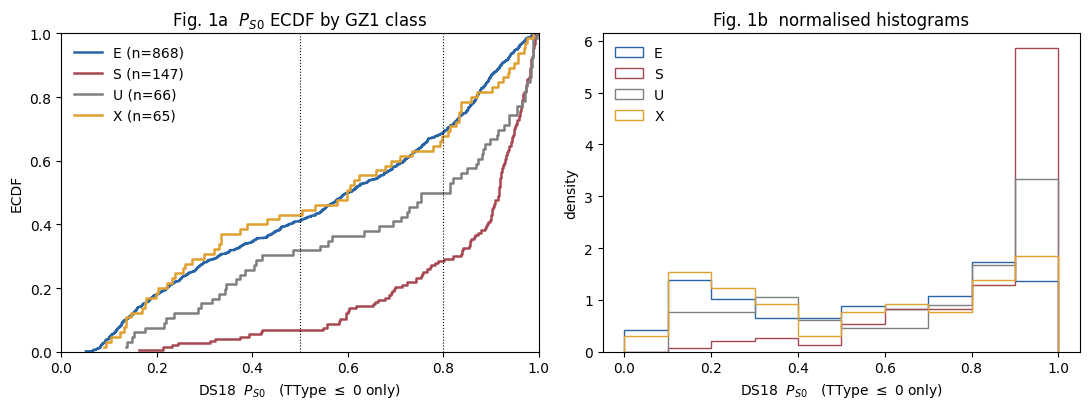

In [15]:
COL = {"E": "#2864A6", "S": "#A74752", "U": "#7F7F7F", "X": "#E0A030"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
for c in CLASSES:
    v = np.sort(early.loc[early.gz1_class == c, "P_S0"].values)
    if len(v):
        ax.step(v, np.arange(1, len(v) + 1) / len(v), where="post", color=COL[c], lw=1.8, label=f"{c} (n={len(v)})")
ax.set_xlabel("DS18  $P_{S0}$   (TType $\\leq$ 0 only)"); ax.set_ylabel("ECDF"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.axvline(0.5, color="k", ls=":", lw=0.8); ax.axvline(0.8, color="k", ls=":", lw=0.8); ax.legend(loc="upper left", frameon=False)
ax.set_title("Fig. 1a  $P_{S0}$ ECDF by GZ1 class")
ax = axes[1]
bins = np.linspace(0, 1, 11)
for c in CLASSES:
    v = early.loc[early.gz1_class == c, "P_S0"].values
    if len(v):
        ax.hist(v, bins=bins, histtype="step", density=True, color=COL[c], lw=1.8, label=c)
ax.set_xlabel("DS18  $P_{S0}$   (TType $\\leq$ 0 only)"); ax.set_ylabel("density"); ax.legend(frameon=False)
ax.set_title("Fig. 1b  normalised histograms")
plt.tight_layout(); plt.show()

### Figure 2 — GZ1 class fractions versus `P_S0` (early types)

Stacked fractions with Wilson 95 % bars and per-bin counts, so sparse bins are visible.
Bins are equal-width in `P_S0` (0.1 wide) — finer than the descriptive bands of §7 — plus the
descriptive bands as a second panel.

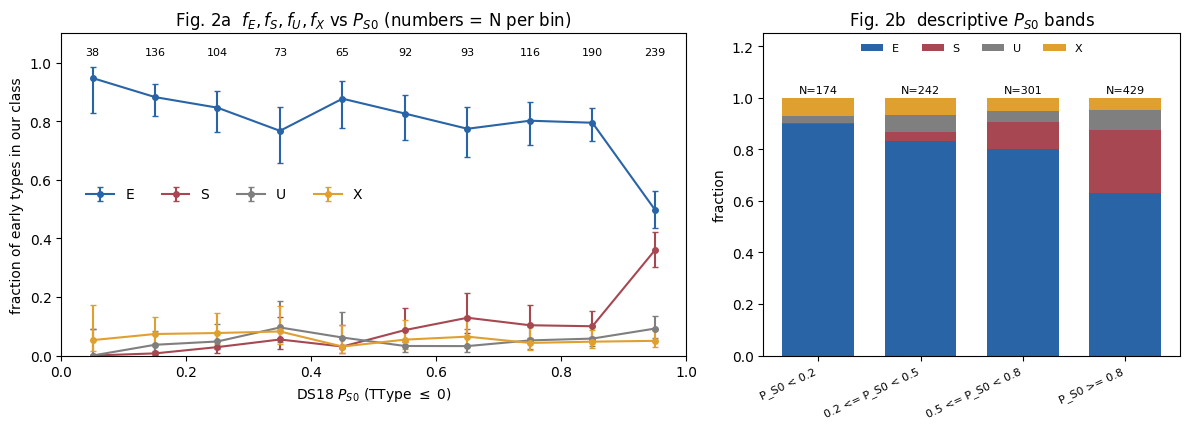

In [16]:
def frac_vs_ps0(df, edges):
    out = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        d = df[(df.P_S0 >= lo) & (df.P_S0 < hi)]
        cf = class_fractions(d, f"[{lo:.1f},{hi:.1f})"); cf["xc"] = 0.5 * (lo + hi); cf["lo_edge"] = lo; cf["hi_edge"] = hi
        out.append(cf)
    return pd.concat(out, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1.5, 1]})
# (a) 0.1-wide bins, lines with CI
ax = axes[0]
fine = frac_vs_ps0(early, np.append(np.linspace(0, 1, 11)[:-1], 1.0001))
for c in CLASSES:
    t = fine[fine.cls == c]
    ax.errorbar(t.xc, t.frac, yerr=[t.frac - t.lo, t.hi - t.frac], color=COL[c], marker="o", ms=4, lw=1.5, capsize=2, label=c)
for _, t in fine[fine.cls == "E"].iterrows():
    ax.text(t.xc, 1.02, f"{t.n}", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, 1.1); ax.set_xlim(0, 1); ax.set_xlabel("DS18 $P_{S0}$ (TType $\\leq$ 0)"); ax.set_ylabel("fraction of early types in our class")
ax.legend(frameon=False, ncol=4, loc="center left", bbox_to_anchor=(0.02, 0.5)); ax.set_title("Fig. 2a  $f_E, f_S, f_U, f_X$ vs $P_{S0}$ (numbers = N per bin)")
# (b) descriptive bands stacked
ax = axes[1]
bottom = np.zeros(len(pivotB)); x = np.arange(len(pivotB))
for c in CLASSES:
    ax.bar(x, pivotB[c].values, bottom=bottom, color=COL[c], label=c, width=0.7); bottom += pivotB[c].values
for i, n in enumerate(pivotB["N"].values):
    ax.text(i, 1.02, f"N={n}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(pivotB.index, rotation=25, ha="right", fontsize=8); ax.set_ylim(0, 1.1); ax.set_ylabel("fraction")
ax.set_ylim(0, 1.25); ax.set_title("Fig. 2b  descriptive $P_{S0}$ bands"); ax.legend(frameon=False, ncol=4, fontsize=8, loc="upper center")
plt.tight_layout(); plt.show()

## 9. Inclination diagnostic (exploratory)

DS18 `P_edge_on` is available for all rows.  Hypothesis: face-on S0s hide their disc and are voted E by
GZ1; inclined S0s reveal it and drift to S or U.  Two views: (i) `P_edge_on` distribution per our class
among high-confidence S0s; (ii) our class fractions in `P_edge_on` bins among the same objects, and
among all early types.

In [17]:
print("P_edge_on coverage among matched:", aud.P_edge_on.notna().mean())
print("\nTType<=0 & P_S0>=0.8: P_edge_on by our class")
print(hi_s0.groupby("gz1_class")["P_edge_on"].describe(percentiles=[0.25, 0.5, 0.75]).reindex(CLASSES).round(3))
print("\nfraction with P_edge_on > 0.5 by our class (high-confidence S0):")
for c in CLASSES:
    d = hi_s0[hi_s0.gz1_class == c]; k = int((d.P_edge_on > 0.5).sum()); lo, hi = wilson(k, len(d))
    print(f"  {c}: {k}/{len(d)} = {100*k/max(len(d),1):.1f}% [{100*lo:.1f}–{100*hi:.1f}]")

from scipy.stats import mannwhitneyu
a = hi_s0.loc[hi_s0.gz1_class == "E", "P_edge_on"]; b = hi_s0.loc[hi_s0.gz1_class != "E", "P_edge_on"]
if len(a) > 5 and len(b) > 5:
    print(f"\nMann-Whitney P_edge_on, E vs non-E (high-confidence S0): U p = {mannwhitneyu(a, b).pvalue:.3g}  (n={len(a)}, {len(b)})")

eo_edges = [0, 0.05, 0.2, 0.5, 0.8, 1.0001]
def eo_table(df, label):
    rows = []
    for lo, hi in zip(eo_edges[:-1], eo_edges[1:]):
        d = df[(df.P_edge_on >= lo) & (df.P_edge_on < hi)]
        r = {"P_edge_on bin": f"[{lo:.2f},{hi:.2f})", "N": len(d)}
        r.update({c: (d.gz1_class == c).mean() if len(d) else np.nan for c in CLASSES}); rows.append(r)
    t = pd.DataFrame(rows).set_index("P_edge_on bin"); print(f"\n{label}: P(our class | P_edge_on bin)"); print(t.round(3)); return t
eo_hi = eo_table(hi_s0, "TType<=0 & P_S0>=0.8"); eo_all = eo_table(early, "all TType<=0")

P_edge_on coverage among matched: 1.0

TType<=0 & P_S0>=0.8: P_edge_on by our class
           count   mean    std  min    25%    50%    75%    max
gz1_class                                                      
E          270.0  0.211  0.313  0.0  0.001  0.020  0.356  0.999
S          105.0  0.534  0.428  0.0  0.003  0.719  0.942  0.999
U           33.0  0.482  0.398  0.0  0.044  0.547  0.902  0.973
X           21.0  0.409  0.408  0.0  0.001  0.288  0.884  0.990

fraction with P_edge_on > 0.5 by our class (high-confidence S0):
  E: 54/270 = 20.0% [15.7–25.2]
  S: 62/105 = 59.0% [49.5–68.0]
  U: 17/33 = 51.5% [35.2–67.5]
  X: 8/21 = 38.1% [20.8–59.1]

Mann-Whitney P_edge_on, E vs non-E (high-confidence S0): U p = 3.62e-09  (n=270, 159)

TType<=0 & P_S0>=0.8: P(our class | P_edge_on bin)
                 N      E      S      U      X
P_edge_on bin                                 
[0.00,0.05)    208  0.755  0.168  0.043  0.034
[0.05,0.20)     38  0.711  0.132  0.105  0.053
[0.20,0.50)   

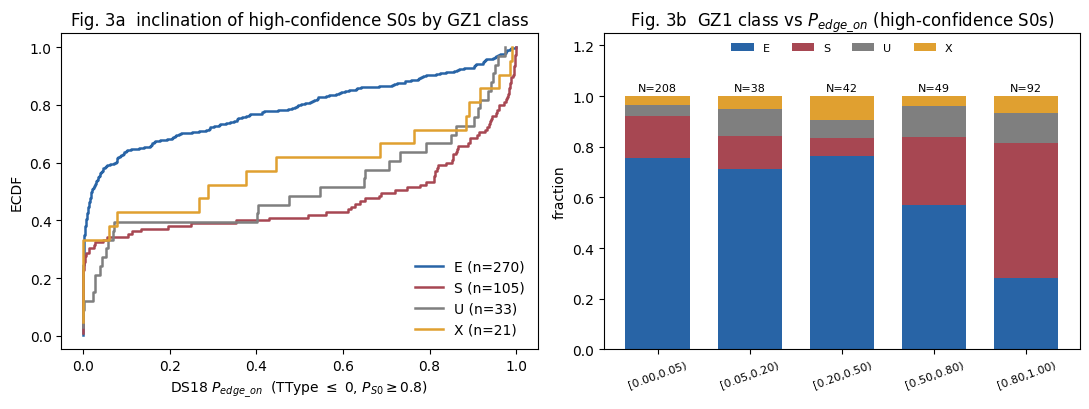

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
for c in CLASSES:
    v = np.sort(hi_s0.loc[hi_s0.gz1_class == c, "P_edge_on"].values)
    if len(v) >= 3:
        ax.step(v, np.arange(1, len(v) + 1) / len(v), where="post", color=COL[c], lw=1.8, label=f"{c} (n={len(v)})")
ax.set_xlabel("DS18 $P_{edge\\_on}$  (TType $\\leq$ 0, $P_{S0} \\geq 0.8$)"); ax.set_ylabel("ECDF"); ax.legend(frameon=False, loc="lower right")
ax.set_title("Fig. 3a  inclination of high-confidence S0s by GZ1 class")
ax = axes[1]
x = np.arange(len(eo_hi)); bottom = np.zeros(len(eo_hi))
for c in CLASSES:
    ax.bar(x, eo_hi[c].fillna(0).values, bottom=bottom, color=COL[c], label=c, width=0.7); bottom += eo_hi[c].fillna(0).values
for i, n in enumerate(eo_hi["N"].values):
    ax.text(i, 1.02, f"N={n}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(eo_hi.index, rotation=20, fontsize=8); ax.set_ylim(0, 1.1); ax.set_ylabel("fraction")
ax.set_ylim(0, 1.25); ax.set_title("Fig. 3b  GZ1 class vs $P_{edge\\_on}$ (high-confidence S0s)"); ax.legend(frameon=False, ncol=4, fontsize=8, loc="upper center")
plt.tight_layout(); plt.show()

## 10. CG versus control diagnostic

Unique galaxies; `CG` = member of CG4, `control` = member of RG4 / Control4B / Control4C and not of CG4
(the two sets are disjoint by construction, see §3).  Descriptive only — CG numbers are small.

In [19]:
def env_block(name, mask):
    d = aud[mask]; e = d[d.early]; h = e[e.P_S0 >= 0.8]; i = e[e.P_S0 > 0.5]
    print(f"== {name}: matched N={len(d)}, early N={len(e)}, P_S0>=0.8 N={len(h)}, P_S0>0.5 N={len(i)}")
    print("  our class mix (all matched):     ", fmt_row(class_fractions(d)))
    print("  TType<=0 & P_S0>=0.8 -> our class:", fmt_row(class_fractions(h)))
    print("  TType<=0 & P_S0>0.5  -> our class:", fmt_row(class_fractions(i)))
    print("  TType<=0 & P_S0<0.2  -> our class:", fmt_row(class_fractions(e[e.P_S0 < 0.2])))
    return d, e, h
cg, cg_e, cg_h = env_block("CG", aud.is_CG)
ct_, ct_e, ct_h = env_block("control", aud.is_control)

print("\nContent of our E class by environment (fractions of E galaxies):")
for name, d in [("CG", cg), ("control", ct_)]:
    E_ = d[d.gz1_class == "E"]; Ee_ = E_[E_.early]
    print(f"  {name:8s} nE={len(E_):4d}  late={100*(E_.TType>0).mean():.1f}%  early={100*E_.early.mean():.1f}%  "
          f"early&P_S0<0.2={100*(E_.early&(E_.P_S0<0.2)).mean():.1f}%  early&P_S0>0.5={100*(E_.early&(E_.P_S0>0.5)).mean():.1f}%  "
          f"early&P_S0>=0.8={100*(E_.early&(E_.P_S0>=0.8)).mean():.1f}%")

# Fisher exact on E vs non-E among high-confidence S0s, CG vs control (descriptive)
from scipy.stats import fisher_exact
tab = np.array([[ (cg_h.gz1_class=="E").sum(), (cg_h.gz1_class!="E").sum() ],
                [ (ct_h.gz1_class=="E").sum(), (ct_h.gz1_class!="E").sum() ]])
print("\nHigh-confidence S0 -> E vs not-E, CG vs control:\n", tab, "\nFisher exact p =", round(fisher_exact(tab)[1], 3))

== CG: matched N=173, early N=99, P_S0>=0.8 N=37, P_S0>0.5 N=64
  our class mix (all matched):      E: 49.7% [42.3–57.1] (86), S: 39.9% [32.9–47.3] (69), U: 2.3% [0.9–5.8] (4), X: 8.1% [4.9–13.1] (14)
  TType<=0 & P_S0>=0.8 -> our class: E: 56.8% [40.9–71.3] (21), S: 29.7% [17.5–45.8] (11), U: 2.7% [0.5–13.8] (1), X: 10.8% [4.3–24.7] (4)
  TType<=0 & P_S0>0.5  -> our class: E: 73.4% [61.5–82.7] (47), S: 17.2% [9.9–28.2] (11), U: 1.6% [0.3–8.3] (1), X: 7.8% [3.4–17.0] (5)
  TType<=0 & P_S0<0.2  -> our class: E: 86.7% [62.1–96.3] (13), S: 0.0% [0.0–20.4] (0), U: 13.3% [3.7–37.9] (2), X: 0.0% [0.0–20.4] (0)
== control: matched N=2263, early N=1047, P_S0>=0.8 N=392, P_S0>0.5 N=666
  our class mix (all matched):      E: 37.8% [35.9–39.8] (856), S: 52.1% [50.1–54.2] (1180), U: 5.1% [4.3–6.1] (115), X: 4.9% [4.1–5.9] (112)
  TType<=0 & P_S0>=0.8 -> our class: E: 63.5% [58.6–68.1] (249), S: 24.0% [20.0–28.4] (94), U: 8.2% [5.8–11.3] (32), X: 4.3% [2.7–6.8] (17)
  TType<=0 & P_S0>0.5  -> our cl

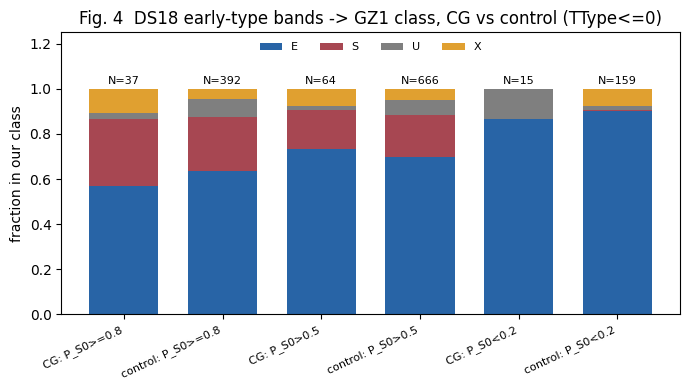

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = ["CG: P_S0>=0.8", "control: P_S0>=0.8", "CG: P_S0>0.5", "control: P_S0>0.5", "CG: P_S0<0.2", "control: P_S0<0.2"]
subs = [cg_h, ct_h, cg_e[cg_e.P_S0 > 0.5], ct_e[ct_e.P_S0 > 0.5], cg_e[cg_e.P_S0 < 0.2], ct_e[ct_e.P_S0 < 0.2]]
x = np.arange(len(labels)); bottom = np.zeros(len(labels))
for c in CLASSES:
    vals = np.array([(s.gz1_class == c).mean() if len(s) else 0 for s in subs])
    ax.bar(x, vals, bottom=bottom, color=COL[c], label=c, width=0.7); bottom += vals
for i, s in enumerate(subs):
    ax.text(i, 1.02, f"N={len(s)}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8); ax.set_ylim(0, 1.1); ax.set_ylabel("fraction in our class")
ax.set_ylim(0, 1.25); ax.set_title("Fig. 4  DS18 early-type bands -> GZ1 class, CG vs control (TType<=0)"); ax.legend(frameon=False, ncol=4, fontsize=8, loc="upper center")
plt.tight_layout(); plt.show()

## 11. Machine-readable summary of the key numbers

Everything quoted in the conclusions is printed here from the in-memory table.

In [21]:
def pct(k, n): return f"{100*k/n:.1f}%" if n else "n/a"
E = aud[aud.gz1_class == "E"]; Ee = E[E.early]
summary = {
  "unique_galaxies": int(len(ours)), "matched_unique": int(len(aud)), "matched_frac": round(len(aud)/len(ours), 3),
  "N_hiS0": int(len(hi_s0)), "hiS0_to_class": {c: pct((hi_s0.gz1_class==c).sum(), len(hi_s0)) for c in CLASSES},
  "N_inclS0": int(len(incl_s0)), "inclS0_to_class": {c: pct((incl_s0.gz1_class==c).sum(), len(incl_s0)) for c in CLASSES},
  "N_pureE": int(len(pure_e)), "pureE_to_class": {c: pct((pure_e.gz1_class==c).sum(), len(pure_e)) for c in CLASSES},
  "N_E": int(len(E)),
  "E_content": {"late TType>0": pct((E.TType>0).sum(), len(E)), "early TType<=0": pct(E.early.sum(), len(E)),
                "early & P_S0<0.2": pct((E.early&(E.P_S0<0.2)).sum(), len(E)), "early & P_S0>0.5": pct((E.early&(E.P_S0>0.5)).sum(), len(E)),
                "early & P_S0>=0.8": pct((E.early&(E.P_S0>=0.8)).sum(), len(E)),
                "P_S0<0.2 | early": pct((Ee.P_S0<0.2).sum(), len(Ee)), "P_S0>=0.8 | early": pct((Ee.P_S0>=0.8).sum(), len(Ee))},
  "hiS0_median_Pedgeon_by_class": {c: round(float(hi_s0.loc[hi_s0.gz1_class==c, "P_edge_on"].median()), 3) for c in CLASSES if (hi_s0.gz1_class==c).sum()},
  "CG_hiS0": {"N": int(len(cg_h)), **{c: pct((cg_h.gz1_class==c).sum(), len(cg_h)) for c in CLASSES}},
  "control_hiS0": {"N": int(len(ct_h)), **{c: pct((ct_h.gz1_class==c).sum(), len(ct_h)) for c in CLASSES}},
}
print(json.dumps(summary, indent=1))

{
 "unique_galaxies": 3857,
 "matched_unique": 2436,
 "matched_frac": 0.632,
 "N_hiS0": 429,
 "hiS0_to_class": {
  "E": "62.9%",
  "S": "24.5%",
  "U": "7.7%",
  "X": "4.9%"
 },
 "N_inclS0": 730,
 "inclS0_to_class": {
  "E": "70.0%",
  "S": "18.8%",
  "U": "6.2%",
  "X": "5.1%"
 },
 "N_pureE": 174,
 "pureE_to_class": {
  "E": "89.7%",
  "S": "0.6%",
  "U": "2.9%",
  "X": "6.9%"
 },
 "N_E": 942,
 "E_content": {
  "late TType>0": "7.9%",
  "early TType<=0": "92.1%",
  "early & P_S0<0.2": "16.6%",
  "early & P_S0>0.5": "54.2%",
  "early & P_S0>=0.8": "28.7%",
  "P_S0<0.2 | early": "18.0%",
  "P_S0>=0.8 | early": "31.1%"
 },
 "hiS0_median_Pedgeon_by_class": {
  "E": 0.02,
  "S": 0.719,
  "U": 0.547,
  "X": 0.288
 },
 "CG_hiS0": {
  "N": 37,
  "E": "56.8%",
  "S": "29.7%",
  "U": "2.7%",
  "X": "10.8%"
 },
 "control_hiS0": {
  "N": 392,
  "E": "63.5%",
  "S": "24.0%",
  "U": "8.2%",
  "X": "4.3%"
 }
}


## 12. Conclusions

All numbers below are printed by the cells above (unique galaxies; Wilson 95 % intervals in brackets).

### Cross-match
* Our four galaxy tables contain **6 076 rows** but only **3 857 unique galaxies** (2 219 repeated
  appearances, all in the control samples; none are shared between CG4 and any control).
* Our `objid` is a **DR16** photometric id (skyVersion 2); DS18 carries a **DR7** `objID` (skyVersion 1).
  A naive id join matches **0** objects.  Using SDSS `PhotoObjDR7`, 3 607 / 3 857 galaxies obtain a
  `dr7objid` (250 have no DR7 counterpart); every DR7 position lies within 0.75″ of ours (median 0.02″).
* **2 436 unique galaxies match DS18** (63 % of the sample; 61 % of E, 72 % of S, 68 % of U, only 30 % of X —
  the `NoGZ` class is largely made of galaxies without a DR7 spectrum/classification).  Ids were handled
  as `int64` / nullable `Int64` throughout; no duplicates on either side.
* **Caveat:** the matched set is the DR7-era subsample (Meert et al. 2015 footprint), so results
  describe our classification *on that subsample*, not necessarily on the 37 % that are unmatched.

### S0 fate — $P(\text{our class}\mid\text{DS18})$
* **Among N = 429 high-confidence DS18 S0 galaxies (`TType ≤ 0`, `P_S0 ≥ 0.8`), 62.9 % [58.3–67.4] are
  classified E, 24.5 % [20.6–28.8] S, 7.7 % [5.5–10.6] U and 4.9 % [3.2–7.4] X by our current GZ1
  classification.**
* Inclusive definition (`TType ≤ 0`, `P_S0 > 0.5`, N = 730): **70.0 % E, 18.8 % S, 6.2 % U, 5.1 % X**.
* Reference "pure E" band (`TType ≤ 0`, `P_S0 < 0.2`, N = 174): **89.7 % E, 0.6 % S, 2.9 % U, 6.9 % X**.
* The E-fraction declines only mildly from 90 % to 80 % across `P_S0` = 0–0.8 and drops sharply
  (to ≈ 50 %) only in the last bin `P_S0 > 0.9` (Fig. 2a); the galaxies that leave E go almost entirely to S.
  DS18 late types (`TType > 0`, N = 1 290) are 85 % S and only 5.7 % E, so the E/S split itself is sound;
  the issue is the E/S0 boundary, which GZ1 was never designed to draw.

### Our E class — $P(\text{DS18}\mid\text{our class})$  (N = 942 matched E galaxies)
* DS18 late type (`TType > 0`): **7.9 %** [6.3–9.7].
* DS18 early type (`TType ≤ 0`): **92.1 %** [90.3–93.7]; median `TType` = −2.2.
* Strongly E-like (early and `P_S0 < 0.2`): **16.6 %** of all E (18.0 % of early E).
* S0-like (early and `P_S0 > 0.5`): **54.2 %** of all E (58.9 % of early E).
* Strongly S0-like (early and `P_S0 ≥ 0.8`): **28.7 %** [25.9–31.6] of all E (31.1 % of early E).
* Median `P_S0` of our early-type E galaxies is 0.60; the interquartile range is 0.27–0.85.
* For comparison, our S class is 88 % DS18 late type; U and X are roughly half early / half late.

### Inclination
* Among high-confidence S0s the ones we call E are strongly **face-on**: median `P_edge_on` = 0.02
  (E) versus 0.72 (S), 0.55 (U), 0.29 (X); only 20 % [16–25] of the E-classified S0s have
  `P_edge_on > 0.5` against 59 % [50–68] of the S-classified ones (Mann–Whitney E vs non-E,
  p ≈ 4 × 10⁻⁹).  In `P_edge_on` bins the E share falls from 75 % (`P_edge_on < 0.05`, N = 208) to
  28 % (`P_edge_on ≥ 0.8`, N = 92) while the S share rises from 17 % to 53 % (Fig. 3b).
* This is a clear, not a weak, trend and matches the hypothesis: face-on S0s look smooth and are
  voted "elliptical" in GZ1; edge-on S0s show their disc and are voted "spiral" (`p_cs` includes the
  GZ1 *edge-on* answer).  It remains exploratory (single catalogue, descriptive bins).

### Environment
* CG (N = 173 matched, 37 high-confidence S0s): high-confidence S0 → **56.8 % E, 29.7 % S, 2.7 % U, 10.8 % X**.
* Control (N = 2 263 matched, 392 high-confidence S0s): → **63.5 % E, 24.0 % S, 8.2 % U, 4.3 % X**.
* Content of E: CG 90.7 % early / 24.4 % strongly S0-like; control 92.3 % early / 29.1 % strongly S0-like.
* Fisher exact test on E vs not-E among high-confidence S0s, CG vs control: p = 0.48.  With 37 CG
  objects the CG intervals are wide (E: 41–71 %); **no material environmental difference in the
  mapping is detectable**, and the numbers are too small to claim one either way.

### Interpretation (from this audit only)
Our GZ1 "Elliptical" class is **specific to early types** (92 % `TType ≤ 0`, 8 % contamination by
DS18 late types) but is **not specific to ellipticals**: by DS18's E-vs-S0 probability, only ~17 %
of our E galaxies are strongly E-like, while ~54 % are more S0-like than E-like and ~29 % are
strongly S0-like.  Conversely, ~63 % of DS18's high-confidence S0s sit in our E class, preferentially
the face-on ones, and the remaining ~25 % that GZ1 sees as discs are labelled S.

So the current terminology "elliptical" is **substantially contaminated by S0s** and, taken literally,
is too ambiguous to justify without qualification.  The evidence supports reading our E / S split as
**"smooth (E + face-on S0)" versus "disc/featured (spirals + inclined S0s)"** — i.e. early-type versus
late-type in GZ1's own sense — rather than E versus non-E.  The relative CG-vs-control comparisons in
the paper are not obviously affected (the mapping is the same in both environments), but any statement
that relies on the class meaning *elliptical* specifically should be re-worded or qualified.

No manuscript, code, configuration, figure or data file has been modified on the basis of these results.

### What this notebook created
* `notebooks/audit_gz1_vs_ds18.ipynb` (this file) — the only change inside the repository.
* Cache outside the repository, safe to delete: `~/.cache/cg_gals_audit/ds18/{ReadMe,catalog.dat.gz}`
  (CDS J/MNRAS/476/3661) and `~/.cache/cg_gals_audit/photoobjdr7_{map.csv,queried_dr8objids.txt}`
  (SDSS DR16 `PhotoObjDR7` DR8→DR7 id mapping for our 3 857 objids).